(a)

In [1]:
import numpy as np

rng = np.random.default_rng(1)  
x = rng.normal(size=100)        
y = x - 2 * x**2 + rng.normal(size=100)  

(b)

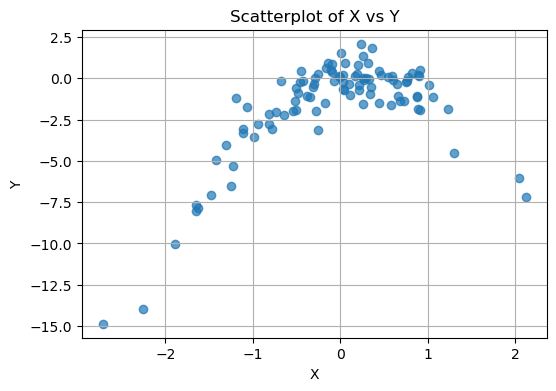

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatterplot of X vs Y")
plt.grid(True)
plt.show()

(c)

In [3]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

loo = LeaveOneOut()

def loocv_error(X, y):
    model = LinearRegression()
    errors = []

    for train_idx, test_idx in loo.split(X):
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[test_idx])
        errors.append((y[test_idx] - y_pred)**2)

    return np.mean(errors)

X1 = x.reshape(-1, 1)
X2 = np.column_stack([x, x**2])
X3 = np.column_stack([x, x**2, x**3])
X4 = np.column_stack([x, x**2, x**3, x**4])

err1 = loocv_error(X1, y)
err2 = loocv_error(X2, y)
err3 = loocv_error(X3, y)
err4 = loocv_error(X4, y)

print("LOOCV Errors:")
print(f"Degree 1: {err1:.4f}")
print(f"Degree 2: {err2:.4f}")
print(f"Degree 3: {err3:.4f}")
print(f"Degree 4: {err4:.4f}")

LOOCV Errors:
Degree 1: 6.6330
Degree 2: 1.1229
Degree 3: 1.3018
Degree 4: 1.3324


(d)

In [4]:
rng = np.random.default_rng(2)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

X1 = x.reshape(-1, 1)
X2 = np.column_stack([x, x**2])
X3 = np.column_stack([x, x**2, x**3])
X4 = np.column_stack([x, x**2, x**3, x**4])

err1 = loocv_error(X1, y)
err2 = loocv_error(X2, y)
err3 = loocv_error(X3, y)
err4 = loocv_error(X4, y)

print("LOOCV Errors with new seed:")
print(f"Degree 1: {err1:.4f}")
print(f"Degree 2: {err2:.4f}")
print(f"Degree 3: {err3:.4f}")
print(f"Degree 4: {err4:.4f}")

LOOCV Errors with new seed:
Degree 1: 7.5606
Degree 2: 0.9840
Degree 3: 0.9682
Degree 4: 0.9660


(e)

二次多項式模型（degree = 2）具有最小的 LOOCV error

(f)

在四個模型中，只有二次模型的主要係數($x^2 ,x$)是統計上顯著的，這反映出資料實際是根據一個二次模型生成的。三次與四次模型中的高階係數大多不顯著，表示這些額外的項沒有提供額外資訊。這與 LOOCV 的結論一致，即二次模型具有最小的預測誤差，而更複雜的模型反而造成 overfitting。